In [1]:
# Load Dataset

import torch
torch.set_default_dtype(torch.float32)

#dataset = torch.load("../datasets/simple_beam/combined_50.pt",weights_only=False)
#dataset_conn = torch.load("../datasets/simple_beam/combined_50_alpha_conn.pt",weights_only=False)
#dataset_val = torch.load("../datasets/simple_beam/combined_test.pt",weights_only=False)

dataset = torch.load("../torchfem_dataset/simple_beam_reduced/combined_200_conn.pt",weights_only=False)
#dataset_conn = torch.load("../torchfem_dataset/simple_beam_reduced/combined_50_conn.pt",weights_only=False)
#dataset_2 = torch.load("../torchfem_dataset/tube_2/tube_combined.pt",weights_only=False)

In [2]:
## Process dataset for training - Nodes only
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import coalesce, to_undirected
from torch_geometric.loader import DataLoader
from torch_geometric.data import HeteroData

def build_laststep_features(data,dtype=torch.float32):
    ## Collapse to peak load timestep
    #print(data.keys)
    len = data['nodes'].f_ext.shape[0]
    t = int(len-1)
    # Nodes: x = [pos, bc, f_ext[-1], f_int[-1]]  (no leakage of u_ts into x)
    #pos   = data['nodes'].pos.to(dtype) #no need to include
    bc    = data['nodes'].bc
    f_ext = torch.Tensor(data['nodes'].f_ext[t]).to(dtype)
    data['nodes'].fext = torch.Tensor(data['nodes'].f_ext[t]).to(dtype)
    data['nodes'].x = torch.cat([bc, f_ext], dim=-1).to(dtype)


    # Target: nodes â†’ u_ts[-1] (3D)
    data['nodes'].y_u = data['nodes'].u_ts[t].to(dtype)
    data['nodes'].y_fint = data['nodes'].f_ts[t].to(dtype)

    # (Optional) free large tensors you won't use further to save RAM/VRAM
    del data['nodes'].bc, data['nodes'].u_ts, data['nodes'].f_ext, data['nodes'].f_int, data['elements'].material#, data['nodes'].pos
    del data['elements'].s_ts, data['elements'].d_ts, data['elements'].material, data['nodes'].f_ts, data['elements'].s_ts, data['elements']
    del data[('nodes','belongs_to','elements')], data[('elements','contributes','nodes')]

    #print(data.keys)

    return data

class HeteroStandardScaler:
    def __init__(self):
        self.node_stats = {}
        self.edge_stats = {}

    def fit(self, dataset):
        node_x = torch.cat([d['nodes'].x[:,3:].float() for d in dataset],dim=0)
        node_f = torch.cat([d['nodes'].y_fint.float() for d in dataset],dim=0)
        node_u = torch.cat([d['nodes'].y_u.float() for d in dataset],dim=0)
        edge_acc = {}
        # compute mean/std
        for data in dataset:

            for etype in data.edge_types:
                if "edge_attr" in data[etype]:
                    edge_acc.setdefault(etype, []).append(data[etype].edge_attr.float())
        
        self.node_stats['nodes_x'] = {
            #"mean": node_x.mean(dim=0, keepdim=True),
            "mean": torch.zeros_like(node_x.mean(dim=0, keepdim=True)),
            "std":  node_x.std(dim=0, keepdim=True) + 1e-8}
        self.node_stats['nodes_f'] = {
            #"mean": node_f.mean(dim=0, keepdim=True),
            "mean": torch.zeros_like(node_f.mean(dim=0, keepdim=True)),
            "std":  node_f.std(dim=0, keepdim=True) + 1e-8}
        self.node_stats['nodes_u'] = {
            #"mean": node_u.mean(dim=0, keepdim=True),
            "mean": torch.zeros_like(node_u.mean(dim=0, keepdim=True)),
            "std":  node_u.std(dim=0, keepdim=True) + 1e-8}

        for etype, mats in edge_acc.items():
            continue
            E = torch.cat(mats, dim=0)
            self.edge_stats[etype] = {
                #"mean": E.mean(dim=0, keepdim=True),
                "mean": torch.zeros_like(E.mean(dim=0, keepdim=True)),
                "std":  E.std(dim=0, keepdim=True) + 1e-8}

    def transform(self, data: HeteroData):
        # apply normalization
        x = data['nodes'].x[:,3:].float()
        m_x = self.node_stats['nodes_x']["mean"]
        s_x = self.node_stats['nodes_x']["std"]
        data['nodes'].x[:,3:] = (x - m_x) / s_x

        y_f = data['nodes'].y_fint.float()
        m_f = self.node_stats['nodes_f']["mean"]
        s_f = self.node_stats['nodes_f']["std"]
        data['nodes'].y_fint = (y_f - m_f) / s_f
        
        y_u = data['nodes'].y_u.float()
        m_u = self.node_stats['nodes_u']["mean"]
        s_u = self.node_stats['nodes_u']["std"]
        data['nodes'].y_u = (y_u - m_u) / s_u

        # edges
        for etype in data.edge_types:
            if etype in self.edge_stats and "edge_attr" in data[etype]:
                e = data[etype].edge_attr.float()
                m = self.edge_stats[etype]["mean"]
                s = self.edge_stats[etype]["std"]
                #data[etype].edge_attr = (e - m) / s

        return data
    
    def inverse_transform(self, data: HeteroData):
        # Nodes
        m, s = self.node_stats["nodes_u"]["mean"], self.node_stats["nodes_u"]["std"]
        data = data * s + m

        return data

def make_undirected(data):
    e = data['nodes','adjacent','nodes']
    ei = torch.cat([e.edge_index, e.edge_index.flip(0)], dim=1)
    ea = torch.cat([e.edge_attr,  -e.edge_attr], dim=0)
    ei, ea = coalesce(ei, ea, num_nodes=data['nodes'].num_nodes, reduce='first')
    #ea = torch.zeros_like(ea)
    data['nodes','adjacent','nodes'].edge_index = ei
    data['nodes','adjacent','nodes'].edge_attr  = ea
    if ('nodes','adjacent_rev','nodes') in data.edge_types:
        del data['nodes','adjacent_rev','nodes']
    return data

def make_undirected_abs(data):
    e = data['nodes','adjacent','nodes']
    ei = e.edge_index
    ea = torch.abs(e.edge_attr)
    ei, ea = to_undirected(ei, edge_attr=ea, num_nodes=data['nodes'].num_nodes)
    data['nodes','adjacent','nodes'].edge_index = ei
    data['nodes','adjacent','nodes'].edge_attr  = ea

    if ('nodes','adjacent_rev','nodes') in data.edge_types:
        del data['nodes','adjacent_rev','nodes']
    return data

scaler = HeteroStandardScaler()
## DataLoader with train/val split
dataset_p = [build_laststep_features(d) for d in dataset]
dataset_p = [make_undirected(d) for d in dataset_p]
#dataset_p = [make_undirected_abs(d) for d in dataset_p] #not used currently
scaler.fit(dataset_p)
dataset_t = [scaler.transform(d) for d in dataset_p]

## test dataset
#dataset_test = [build_laststep_features(d) for d in dataset_val]
#dataset_test = [make_undirected(d) for d in dataset_test]
#dataset_t = [scaler.transform(d) for d in dataset_test]

def split_dataset(dataset, val_ratio=0.1, shuffle=True):
    n = len(dataset)
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    n_val = max(1, int(n * val_ratio))
    val_idx = idx[:n_val].tolist()
    train_idx = idx[n_val:].tolist()
    train_set = [dataset[i] for i in train_idx]
    val_set   = [dataset[i] for i in val_idx]
    return train_set, val_set

train_set, val_set = split_dataset(dataset_t, val_ratio=0.1)
#train_set, val_set = split_dataset(dataset_conn, val_ratio=0.1)

In [2]:
## Process dataset for training - min-max normalization
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import coalesce, to_undirected
from torch_geometric.loader import DataLoader
from torch_geometric.data import HeteroData

def build_laststep_features(data,dtype=torch.float32):
    ## Collapse to peak load timestep
    #print(data.keys)
    len = data['nodes'].f_ext.shape[0]
    t = int(len-1)
    # Nodes: x = [pos, bc, f_ext[-1], f_int[-1]]  (no leakage of u_ts into x)
    #pos   = data['nodes'].pos.to(dtype) #no need to include
    bc    = data['nodes'].bc
    f_ext = torch.Tensor(data['nodes'].f_ext[t]).to(dtype)
    data['nodes'].fext = torch.Tensor(data['nodes'].f_ext[t]).to(dtype)
    data['nodes'].x = torch.cat([bc, f_ext], dim=-1).to(dtype)


    # Target: nodes â†’ u_ts[-1] (3D)
    data['nodes'].y_u = data['nodes'].u_ts[t].to(dtype)
    data['nodes'].y_fint = data['nodes'].f_ts[t].to(dtype)

    # (Optional) free large tensors you won't use further to save RAM/VRAM
    del data['nodes'].bc, data['nodes'].u_ts, data['nodes'].f_ext, data['nodes'].f_int, data['elements'].material#, data['nodes'].pos
    del data['elements'].s_ts, data['elements'].d_ts, data['elements'].material, data['nodes'].f_ts, data['elements'].s_ts, data['elements']
    del data[('nodes','belongs_to','elements')], data[('elements','contributes','nodes')]

    #print(data.keys)

    return data

def build_timestep_features(data,dtype=torch.float32):
    ## Split data into single timestep
    #print(data.keys)
    len = data['nodes'].f_ext.shape[0]
    data_ts = []
    for t in range(1,len-1):
        # Nodes: x = [pos, bc, f_ext[-1], f_int[-1]]  (no leakage of u_ts into x)
        #pos   = data['nodes'].pos.to(dtype) #no need to include
        d = data.clone()
        bc    = d['nodes'].bc
        f_ext = torch.Tensor(d['nodes'].f_ext[t]).to(dtype)
        d['nodes'].fext = torch.Tensor(d['nodes'].f_ext[t]).to(dtype)
        d['nodes'].x = torch.cat([bc, f_ext], dim=-1).to(dtype)

        # Target: nodes â†’ u_ts[-1] (3D)
        d['nodes'].y_u = d['nodes'].u_ts[t].to(dtype)
        d['nodes'].y_fint = d['nodes'].f_ts[t].to(dtype)
        del d['nodes'].bc, d['nodes'].u_ts, d['nodes'].f_ext, d['nodes'].f_int, d['elements'].material#, data['nodes'].pos
        del d['elements'].s_ts, d['elements'].d_ts, d['elements'].material, d['nodes'].f_ts, d['elements'].s_ts, d['elements']
        del d[('nodes','belongs_to','elements')], d[('elements','contributes','nodes')]
        data_ts.append(d)


    # (Optional) free large tensors you won't use further to save RAM/VRAM
    del data['nodes'].bc, data['nodes'].u_ts, data['nodes'].f_ext, data['nodes'].f_int, data['elements'].material#, data['nodes'].pos
    del data['elements'].s_ts, data['elements'].d_ts, data['elements'].material, data['nodes'].f_ts, data['elements'].s_ts, data['elements']
    del data[('nodes','belongs_to','elements')], data[('elements','contributes','nodes')]

    #print(data.keys)

    return data_ts

class HeteroStandardScaler:
    def __init__(self):
        self.node_stats = {}
        self.edge_stats = {}

    def fit(self, dataset):
        node_x = torch.cat([d['nodes'].x[:,3:].float() for d in dataset],dim=0)
        node_f = torch.cat([d['nodes'].y_fint.float() for d in dataset],dim=0)
        node_u = torch.cat([d['nodes'].y_u.float() for d in dataset],dim=0)
        edge_acc = {}
        # compute mean/std
        for data in dataset:

            for etype in data.edge_types:
                if "edge_attr" in data[etype]:
                    edge_acc.setdefault(etype, []).append(data[etype].edge_attr.float())
        
        self.node_stats['nodes_x'] = {
            "mean": torch.zeros_like(node_x.mean(dim=0, keepdim=True)),
            "std":  node_x.std(dim=0, keepdim=True) + 1e-8,
            #"max": node_x.abs().max(dim=0, keepdim=True).values}
            "max": node_x.abs().quantile(1, dim=0, keepdim=True)}
        self.node_stats['nodes_f'] = {
            "mean": torch.zeros_like(node_f.mean(dim=0, keepdim=True)),
            "std":  node_f.std(dim=0, keepdim=True) + 1e-8,
            #"max": node_f.abs().max(dim=0, keepdim=True).values}
            "max": node_f.abs().quantile(1, dim=0, keepdim=True)}
        self.node_stats['nodes_u'] = {
            "mean": torch.zeros_like(node_u.mean(dim=0, keepdim=True)),
            "std":  node_u.std(dim=0, keepdim=True) + 1e-8,
            #"max": node_u.abs().max(dim=0, keepdim=True).values}
            "max": node_u.abs().quantile(1, dim=0, keepdim=True)}

        for etype, mats in edge_acc.items():
            continue
            E = torch.cat(mats, dim=0)
            self.edge_stats[etype] = {
                #"mean": E.mean(dim=0, keepdim=True),
                "mean": torch.zeros_like(E.mean(dim=0, keepdim=True)),
                "std":  E.std(dim=0, keepdim=True) + 1e-8}

    def transform(self, data: HeteroData):
        x = data['nodes'].x[:,3:].float()
        max_x = self.node_stats['nodes_x']["max"].clamp_min(1e-8)
        data['nodes'].x[:,3:] = x / max_x

        y_f = data['nodes'].y_fint.float()
        max_f = self.node_stats['nodes_f']["max"].clamp_min(1e-8)
        data['nodes'].y_fint = y_f / max_f
        
        y_u = data['nodes'].y_u.float()
        max_u = self.node_stats['nodes_u']["max"].clamp_min(1e-8)
        data['nodes'].y_u = y_u / max_u

        # edges
        for etype in data.edge_types:
            continue
            if etype in self.edge_stats and "edge_attr" in data[etype]:
                e = data[etype].edge_attr.float()
                m = self.edge_stats[etype]["mean"]
                s = self.edge_stats[etype]["std"]
                data[etype].edge_attr = (e - m) / s

        return data
    
    def inverse_transform(self, data: HeteroData):
        # Nodes
        m = self.node_stats["nodes_u"]["max"]
        data = data * m

        return data

def make_undirected(data):
    e = data['nodes','adjacent','nodes']
    ei = torch.cat([e.edge_index, e.edge_index.flip(0)], dim=1)
    ea = torch.cat([e.edge_attr,  -e.edge_attr], dim=0)
    ei, ea = coalesce(ei, ea, num_nodes=data['nodes'].num_nodes, reduce='first')
    #ea = torch.zeros_like(ea)
    data['nodes','adjacent','nodes'].edge_index = ei
    data['nodes','adjacent','nodes'].edge_attr  = ea
    if ('nodes','adjacent_rev','nodes') in data.edge_types:
        del data['nodes','adjacent_rev','nodes']
    return data

def make_undirected_abs(data):
    e = data['nodes','adjacent','nodes']
    ei = e.edge_index
    ea = torch.abs(e.edge_attr)
    ei, ea = to_undirected(ei, edge_attr=ea, num_nodes=data['nodes'].num_nodes)
    data['nodes','adjacent','nodes'].edge_index = ei
    data['nodes','adjacent','nodes'].edge_attr  = ea

    if ('nodes','adjacent_rev','nodes') in data.edge_types:
        del data['nodes','adjacent_rev','nodes']
    return data

scaler = HeteroStandardScaler()
## DataLoader with train/val split
dataset_p = [build_timestep_features(d) for d in dataset]
dataset_f = [row[-1] for row in dataset_p]
dataset_p = [item for row in dataset_p for item in row]
dataset_p = [make_undirected(d) for d in dataset_f]
#dataset_p = [make_undirected_abs(d) for d in dataset_p] #not used currently
scaler.fit(dataset_f)
dataset_t = [scaler.transform(d) for d in dataset_p]

## test dataset
#dataset_test = [build_laststep_features(d) for d in dataset_val]
#dataset_test = [make_undirected(d) for d in dataset_test]
#dataset_t = [scaler.transform(d) for d in dataset_test]

def split_dataset(dataset, val_ratio=0.1, shuffle=True):
    n = len(dataset)
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    n_val = max(1, int(n * val_ratio))
    val_idx = idx[:n_val].tolist()
    train_idx = idx[n_val:].tolist()
    train_set = [dataset[i] for i in train_idx]
    val_set   = [dataset[i] for i in val_idx]
    return train_set, val_set

train_set, val_set = split_dataset(dataset_t, val_ratio=0.1)
#train_set, val_set = split_dataset(dataset_conn, val_ratio=0.1)

In [3]:
from torch_geometric.utils import is_undirected

ei = train_set[0]['nodes','adjacent','nodes']['edge_index'].T
ea = train_set[0]['nodes','adjacent','nodes']['edge_attr']
edge_index = train_set[0]['nodes','adjacent','nodes'].edge_index
print('Undirected?' if is_undirected(edge_index) else 'Directed!')

Undirected?


In [2]:
## Process dataset for training - with topological information
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import coalesce
from torch_geometric.loader import DataLoader
from torch_geometric.data import HeteroData

def build_laststep_features(data,dtype=torch.float32):
    ## Collapse to peak load timestep
    #print(data.keys)
    len = data['nodes'].f_ext.shape[0]
    t = int(len-1)
    # Nodes: x = [pos, bc, f_ext[-1], f_int[-1]]  (no leakage of u_ts into x)
    #pos   = data['nodes'].pos.to(dtype) #no need to include
    bc    = data['nodes'].bc
    tpl    = data['nodes'].tpl.to(dtype)
    f_ext = torch.Tensor(data['nodes'].f_ext[t]).to(dtype)
    data['nodes'].fext = torch.Tensor(data['nodes'].f_ext[t]).to(dtype)
    data['nodes'].x = torch.cat([bc, f_ext, tpl], dim=-1)


    # Target: nodes â†’ u_ts[-1] (3D)
    data['nodes'].y_u = data['nodes'].u_ts[t].to(dtype)
    data['nodes'].y_fint = data['nodes'].f_ts[t].to(dtype)

    # (Optional) free large tensors you won't use further to save RAM/VRAM
    del data['nodes'].bc, data['nodes'].u_ts, data['nodes'].f_ext, data['nodes'].f_int, data['elements'].material#, data['nodes'].pos
    del data['elements'].s_ts, data['elements'].d_ts, data['elements'].material, data['nodes'].f_ts, data['elements'].s_ts, data['elements']
    del data[('nodes','belongs_to','elements')], data[('elements','contributes','nodes')]

    #print(data.keys)

    return data

class HeteroStandardScaler:
    def __init__(self):
        self.node_stats = {}
        self.edge_stats = {}

    def fit(self, dataset):
        node_x = torch.cat([d['nodes'].x[:,3:].float() for d in dataset],dim=0)
        node_f = torch.cat([d['nodes'].y_fint.float() for d in dataset],dim=0)
        node_u = torch.cat([d['nodes'].y_u.float() for d in dataset],dim=0)
        edge_acc = {}
        # compute mean/std
        for data in dataset:

            for etype in data.edge_types:
                if "edge_attr" in data[etype]:
                    edge_acc.setdefault(etype, []).append(data[etype].edge_attr.float())
        
        self.node_stats['nodes_x'] = {
            #"mean": node_x.mean(dim=0, keepdim=True),
            "mean": torch.zeros_like(node_x.mean(dim=0, keepdim=True)),
            "std":  node_x.std(dim=0, keepdim=True) + 1e-8}
        self.node_stats['nodes_f'] = {
            #"mean": node_f.mean(dim=0, keepdim=True),
            "mean": torch.zeros_like(node_f.mean(dim=0, keepdim=True)),
            "std":  node_f.std(dim=0, keepdim=True) + 1e-8}
        self.node_stats['nodes_u'] = {
            #"mean": node_u.mean(dim=0, keepdim=True),
            "mean": torch.zeros_like(node_u.mean(dim=0, keepdim=True)),
            "std":  node_u.std(dim=0, keepdim=True) + 1e-8}

        for etype, mats in edge_acc.items():
            E = torch.cat(mats, dim=0)
            self.edge_stats[etype] = {
                #"mean": E.mean(dim=0, keepdim=True),
                "mean": torch.zeros_like(E.mean(dim=0, keepdim=True)),
                "std":  E.std(dim=0, keepdim=True) + 1e-8}


    def transform(self, data: HeteroData):
        # apply normalization
        x = data['nodes'].x[:,3:].float()
        m_x = self.node_stats['nodes_x']["mean"]
        s_x = self.node_stats['nodes_x']["std"]
        data['nodes'].x[:,3:] = (x - m_x) / s_x

        y_f = data['nodes'].y_fint.float()
        m_f = self.node_stats['nodes_f']["mean"]
        s_f = self.node_stats['nodes_f']["std"]
        data['nodes'].y_fint = (y_f - m_f) / s_f
        
        y_u = data['nodes'].y_u.float()
        m_u = self.node_stats['nodes_u']["mean"]
        s_u = self.node_stats['nodes_u']["std"]
        data['nodes'].y_u = (y_u - m_u) / s_u

        # edges
        for etype in data.edge_types:
            if etype in self.edge_stats and "edge_attr" in data[etype]:
                e = data[etype].edge_attr.float()
                m = self.edge_stats[etype]["mean"]
                s = self.edge_stats[etype]["std"]
                data[etype].edge_attr = (e - m) / s

        return data
    
    def inverse_transform(self, data: HeteroData):
        # Nodes
        m, s = self.node_stats["nodes_u"]["mean"], self.node_stats["nodes_u"]["std"]
        data = data * s + m

        return data

def make_undirected(data):
    e = data['nodes','adjacent','nodes']
    ei = torch.cat([e.edge_index, e.edge_index.flip(0)], dim=1)
    ea = torch.cat([e.edge_attr,  -e.edge_attr], dim=0)
    ei, ea = coalesce(ei, ea, num_nodes=data['nodes'].num_nodes, reduce='first')
    data['nodes','adjacent','nodes'].edge_index = ei
    data['nodes','adjacent','nodes'].edge_attr  = ea
    if ('nodes','adjacent_rev','nodes') in data.edge_types:
        del data['nodes','adjacent_rev','nodes']
    return data

scaler = HeteroStandardScaler()
## DataLoader with train/val split
dataset_p = [build_laststep_features(d) for d in dataset]
dataset_p = [make_undirected(d) for d in dataset_p]
scaler.fit(dataset_p)
dataset_t = [scaler.transform(d) for d in dataset_p]

def split_dataset(dataset, val_ratio=0.1, shuffle=True):
    n = len(dataset)
    idx = torch.randperm(n) if shuffle else torch.arange(n)
    n_val = max(1, int(n * val_ratio))
    val_idx = idx[:n_val].tolist()
    train_idx = idx[n_val:].tolist()
    train_set = [dataset[i] for i in train_idx]
    val_set   = [dataset[i] for i in val_idx]
    return train_set, val_set

# preprocess first
train_set, val_set = split_dataset(dataset_t, val_ratio=0.1)
#train_set, val_set = split_dataset(dataset_conn, val_ratio=0.1)

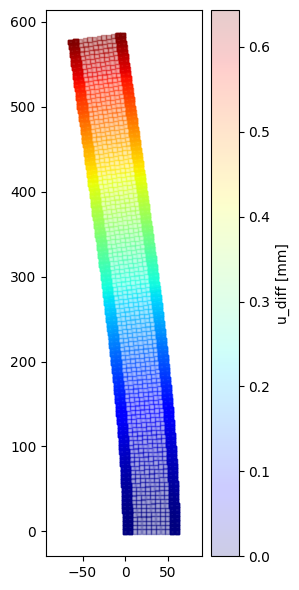

In [4]:
import matplotlib.pyplot as plt
import numpy as np
dataset_n = [scaler.inverse_transform(d['nodes']['y_u']) for d in dataset_t]
for i,out_sample in enumerate(dataset_t):

    fig = plt.figure(figsize=(3, 6))
    #plt.title(f'Sample {sample}',fontsize=10)

    #sc = ax.scatter(out_samples[sample]['nodes']['pos'],'k',alpha=0.3,label='initial position')
    #ax[i,1].plot(out_samples[sample]['nodes']['pred_u'][:],alpha=0.3,label='predicted')

    #ax.plot_trisurf(V[:,0],V[:,1],V[:,2],triangles=F,edgecolor='#888888',linewidth=lw,antialiased=True,color='#dddddd',alpha=0.1)

    vis_scale = 100

    pos_init = out_sample['nodes']['pos']
    pos_true = pos_init+dataset_n[i]*vis_scale
    pos_diff = np.linalg.norm(dataset_n[i],axis=-1)

    #force_true = out_sample['nodes']['f_ts'][ts]
    #force_diff = np.linalg.norm(force_true,axis=-1)

    #sc = ax.scatter(pos_init[:,0],pos_init[:,1],pos_init[:,2],s=2,marker='s',c='#1111dd',alpha=0.2,depthshade=True)
    #sc2 = ax.scatter(pos_true[:,0],pos_true[:,1],pos_true[:,2],s=2,marker='s',c='#11dd11',alpha=0.1,depthshade=True)
    #sc3 = ax.scatter(pos_pred[:,0],pos_pred[:,1],pos_pred[:,2],s=2,marker='s',c='#dd1111',alpha=0.2,depthshade=True)
    sc = plt.scatter(pos_true[:,1],pos_true[:,2],s=10,marker='s',c=pos_diff,cmap='jet',alpha=0.2)
    plt.colorbar(sc, label='u_diff [mm]')

    plt.axis('equal')

    plt.tight_layout()
    plt.show()
    break

In [6]:
train_set, val_set = split_dataset(dataset_t, val_ratio=0.1)
print(train_set[10])

HeteroData(
  nodes={
    pos=[7852, 3],
    fext=[7852, 3],
    x=[7852, 6],
    y_u=[7852, 3],
    y_fint=[7852, 3],
  },
  (nodes, adjacent, nodes)={
    edge_index=[2, 68202],
    edge_attr=[68202, 3],
  }
)


In [ ]:
# Model with pooling
import torch
import torch.nn.functional as F
from torch.nn import ModuleList

from torch_geometric.nn import pool
import torch_geometric.transforms as T
from torch_geometric.nn import MLP, GENConv, to_hetero, MessageNorm

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
#device = torch.device('cpu')
#device = torch.device('mps')

class GNN(torch.nn.Module):
    def __init__(self, in_channels,edge_in,layers,latent_dim, out_channels):
        super().__init__()
        #self.proj = nn.Linear(in_channels, latent_dim)
        #self.edge_proj = nn.Linear(edge_in, latent_dim)

        self.proj = MLP(in_channels=in_channels,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='relu',norm='layer')
        self.edge_proj = MLP(in_channels=edge_in,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='relu',norm='layer')
        self.layers = layers
        self.msg_norm = MessageNorm(learn_scale=True)

        self.encoding_layers = ModuleList([
            GENConv(latent_dim * 2, latent_dim, norm='layer',msg_norm=True)
            for _ in range(layers)])
        self.dropout = torch.nn.Dropout(p=0.1)

        #self.conv1 = GENConv(latent_dim,latent_dim,edge_dim=latent_dim) #num_layers=layers
        self.conv2 = GENConv(latent_dim,out_channels,edge_dim=latent_dim) #num_layers=layers

    

    def forward(self,x,edge_index,edge_attr, batch):
        #x = torch.relu(self.proj(x))
        #edge_attr = torch.relu(self.edge_proj(edge_attr))
        x = self.proj(x)
        edge_attr = self.edge_proj(edge_attr)
        
        for conv in self.encoding_layers:
            x_global = pool.global_mean_pool(x,batch)
            x_expanded = x_global[batch]
            m = conv(torch.cat([x, x_expanded], dim=1), edge_index, edge_attr=edge_attr)
            m = self.msg_norm(x, m)          # normalize messages
            x = x + m                            # residual
            x = self.dropout(x)
        #for _ in range(self.layers):
        #    x = torch.relu(self.conv1(x,edge_index,edge_attr))
        x = self.conv2(x, edge_index, edge_attr)
        return x
    
##TODO: 
# deeper model - test message passing steps vs. error
# mean pooling - in encoding step: see GABI repo; magedgepooling

##later:
# element stresses simple MLP
# force-based calcs & sequential input


model = GNN(in_channels=6,edge_in=3,layers=12,latent_dim=128,out_channels=3).to(device)
#model = to_hetero(model,dataset_t[0].metadata(),aggr='sum')

In [44]:
# Model with global pooling
import torch
import torch.nn.functional as F
from torch.nn import ModuleList

from torch_geometric.nn import pool
import torch_geometric.transforms as T
from torch_geometric.nn import MLP, GENConv, to_hetero, MessageNorm

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
#device = torch.device('cpu')
#device = torch.device('mps')

class GNN(torch.nn.Module):
    def __init__(self, in_channels,edge_in,layers,latent_dim, out_channels):
        super().__init__()
        #self.proj = nn.Linear(in_channels, latent_dim)
        #self.edge_proj = nn.Linear(edge_in, latent_dim)

        self.proj = MLP(in_channels=in_channels,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='leaky_relu',norm='layer')
        self.edge_proj = MLP(in_channels=edge_in,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='leaky_relu',norm='layer')
        self.global_mlp = MLP(in_channels=latent_dim,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='leaky_relu',norm='layer')
        self.layers = layers
        self.msg_norm = MessageNorm(learn_scale=True)

        self.encoding_layers = ModuleList([
            GENConv(latent_dim * 2, latent_dim, norm='layer',msg_norm=True,aggr='softmax',t=1.0,learn_t=True,learn_p=True,num_layers=2)
            for _ in range(layers)])
        self.dropout = torch.nn.Dropout(p=0.2)

        #self.conv1 = GENConv(latent_dim,latent_dim,edge_dim=latent_dim) #num_layers=layers
        self.conv2 = GENConv(latent_dim,out_channels,edge_dim=latent_dim) #num_layers=layers

    

    def forward(self,x,edge_index,edge_attr, batch):
        #x = torch.relu(self.proj(x))
        #edge_attr = torch.relu(self.edge_proj(edge_attr))
        x = self.proj(x)
        edge_attr = self.edge_proj(edge_attr)
        
        for conv in self.encoding_layers:
            g = pool.global_mean_pool(x,batch)
            g = self.global_mlp(g)
            x_expanded = g[batch]
            m = conv(torch.cat([x, x_expanded], dim=1), edge_index, edge_attr=edge_attr)
            m = self.msg_norm(x, m)
            x = x + m
            x = self.dropout(x)
        #for _ in range(self.layers):
        #    x = torch.relu(self.conv1(x,edge_index,edge_attr))
        x = self.conv2(x, edge_index, edge_attr)
        return x
    
##TODO: 
# deeper model - test message passing steps vs. error
# mean pooling - in encoding step: see GABI repo; magedgepooling

##later:
# element stresses simple MLP
# force-based calcs & sequential input


model = GNN(in_channels=6,edge_in=3,layers=12,latent_dim=128,out_channels=3).to(device)
#model = to_hetero(model,dataset_t[0].metadata(),aggr='sum')

In [63]:
# Model without pooling
import torch
import torch.nn.functional as F
from torch.nn import ModuleList

from torch_geometric.nn import pool
import torch_geometric.transforms as T
from torch_geometric.nn import MLP, GENConv, to_hetero, MessageNorm

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
#device = torch.device('cpu')
#device = torch.device('mps')

class GNN(torch.nn.Module):
    def __init__(self, in_channels,edge_in,layers,latent_dim, out_channels):
        super().__init__()
        #self.proj = nn.Linear(in_channels, latent_dim)
        #self.edge_proj = nn.Linear(edge_in, latent_dim)

        self.proj = MLP(in_channels=in_channels,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='relu',norm='layer')
        self.edge_proj = MLP(in_channels=edge_in,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='relu',norm='layer')
        self.layers = layers
        self.msg_norm = MessageNorm(learn_scale=True)

        self.encoding_layers = ModuleList([
            GENConv(latent_dim, latent_dim, norm='layer',msg_norm=True)
            for _ in range(layers)])
        self.dropout = torch.nn.Dropout(p=0.1)

        #self.conv1 = GENConv(latent_dim,latent_dim,edge_dim=latent_dim) #num_layers=layers
        self.conv2 = GENConv(latent_dim,out_channels,edge_dim=latent_dim) #num_layers=layers

    

    def forward(self,x,edge_index,edge_attr, batch):
        #x = torch.relu(self.proj(x))
        #edge_attr = torch.relu(self.edge_proj(edge_attr))
        x = self.proj(x)
        edge_attr = self.edge_proj(edge_attr)
        
        for conv in self.encoding_layers:
            m = conv(x, edge_index, edge_attr=edge_attr)
            m = self.msg_norm(x, m)
            x = x + m
            x = self.dropout(x)
        #for _ in range(self.layers):
        #    x = torch.relu(self.conv1(x,edge_index,edge_attr))
        x = self.conv2(x, edge_index, edge_attr)
        return x
    
##TODO: 
# deeper model - test message passing steps vs. error
# mean pooling - in encoding step: see GABI repo; magedgepooling

##later:
# element stresses simple MLP
# force-based calcs & sequential input


model = GNN(in_channels=6,edge_in=3,layers=12,latent_dim=128,out_channels=3).to(device)
#model = to_hetero(model,dataset_t[0].metadata(),aggr='sum')

In [3]:
# Model updated 1208
import torch
import torch.nn.functional as F
from torch.nn import ModuleList

from torch_geometric.nn import pool
import torch_geometric.transforms as T
from torch_geometric.nn import MLP, GENConv, to_hetero, MessageNorm

device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

class GNN(torch.nn.Module):
    def __init__(self, in_channels,edge_in,layers,latent_dim, out_channels):
        super().__init__()
        #self.proj = nn.Linear(in_channels, latent_dim)
        #self.edge_proj = nn.Linear(edge_in, latent_dim)

        self.proj = MLP(in_channels=in_channels,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='leaky_relu',norm='layer')
        self.edge_proj = MLP(in_channels=edge_in,hidden_channels=latent_dim,out_channels=latent_dim,num_layers=2,act='leaky_relu',norm='layer')
        self.layers = layers
        #self.msg_norm = MessageNorm(learn_scale=True)

        self.encoding_layers = ModuleList([
            GENConv(latent_dim * 2, latent_dim, norm='layer',msg_norm=True,edge_dim=latent_dim)
            for _ in range(layers)])
        #self.dropout = torch.nn.Dropout(p=0.1)

        #self.conv1 = GENConv(latent_dim,latent_dim,edge_dim=latent_dim) #num_layers=layers
        #self.conv2 = GENConv(latent_dim,out_channels,edge_dim=latent_dim) #num_layers=layers
        #self.inv_proj = MLP(in_channels=latent_dim,hidden_channels=latent_dim,out_channels=out_channels,num_layers=2,act='leaky_relu',norm='layer')
        self.inv_proj = MLP(in_channels=latent_dim,hidden_channels=latent_dim,out_channels=out_channels,num_layers=2,act='leaky_relu',plain_last=True)
    

    def forward(self,x,edge_index,edge_attr, batch):
        #x = torch.relu(self.proj(x))
        #edge_attr = torch.relu(self.edge_proj(edge_attr))
        x = self.proj(x)
        edge_attr = self.edge_proj(edge_attr)
        
        for conv in self.encoding_layers:
            x_global = pool.global_mean_pool(x,batch)
            x_expanded = x_global[batch]
            m = conv(torch.cat([x, x_expanded], dim=1), edge_index, edge_attr=edge_attr)
            x = x + m
        x = self.inv_proj(x)
        return x

model = GNN(in_channels=6,edge_in=3,layers=12,latent_dim=128,out_channels=3).to(device)

In [4]:
from copy import deepcopy
from pathlib import Path

alias = '1220_pool_conn'
ckpt_path = Path(f"../genconv/{alias}/weights_2000.pt")
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model.eval()

#train_set, val_set = split_dataset(dataset_val, val_ratio=0.1)
train_loader = DataLoader(train_set, batch_size=1, shuffle=False)
#original_loader = DataLoader(dataset, batch_size=1, shuffle=False)

out_samples = []
with torch.no_grad():
    for data in train_loader:
        d = deepcopy(data)
        d = d.to(device)
        x = d['nodes'].x
        edge_index = d[("nodes", "adjacent", "nodes")].edge_index
        edge_attr = d[("nodes", "adjacent", "nodes")].edge_attr
        #edge_index = data.edge_index_dict.values()
        #edge_attr = data.edge_attr_dict.values()
        batch = d['nodes'].batch

        #print(x.dtype,edge_index.dtype,edge_attr.dtype,batch.dtype)
        pred = model(x, edge_index,edge_attr,batch)

        # Detach and move predictions to CPU for saving
        d['nodes'].pred_u = pred

        d['nodes'].y_u = scaler.inverse_transform(d['nodes'].y_u.cpu())
        d['nodes'].pred_u = scaler.inverse_transform(d['nodes'].pred_u.cpu())
        # Move the data structure back to CPU before attaching CPU tensors
        d = d.to('cpu')

        # Attach predictions into the dictionary

        out_samples.append(d)

# Save to a new file
#save_path = "../base/test_dataset/preds_1208_conn.pt"
save_path = f"../genconv/{alias}/preds_{alias}.pt"
torch.save(out_samples, save_path)
print(f"Saved {len(out_samples)} samples with predictions to {save_path}")

Saved 133 samples with predictions to ../genconv/1220_pool_conn/preds_1220_pool_conn.pt


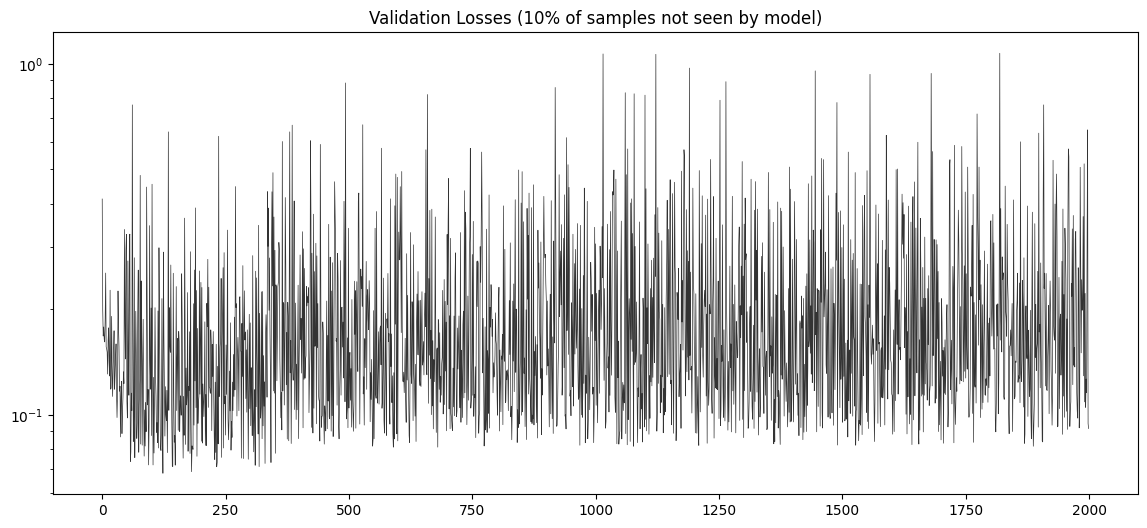

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
loss_1214_conn = pd.read_csv('../genconv/1217_pool_edgedim/losses.csv')
plt.figure(figsize=(14,6))
plt.yscale('log')
plt.title('Validation Losses (10% of samples not seen by model)')
plt.plot(loss_1214_conn['val_loss'],label='Global Pooling, No Coarse Connections',color='#000000',alpha=0.8,linewidth=0.5)

(0.0, 2000.0)

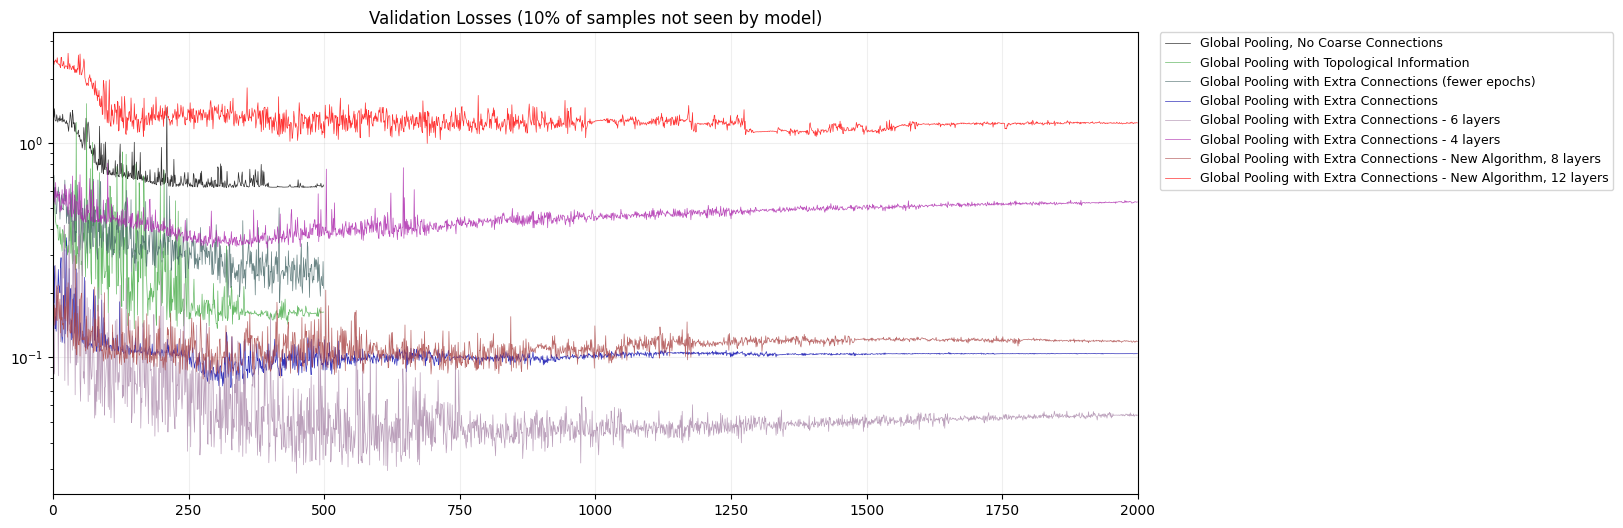

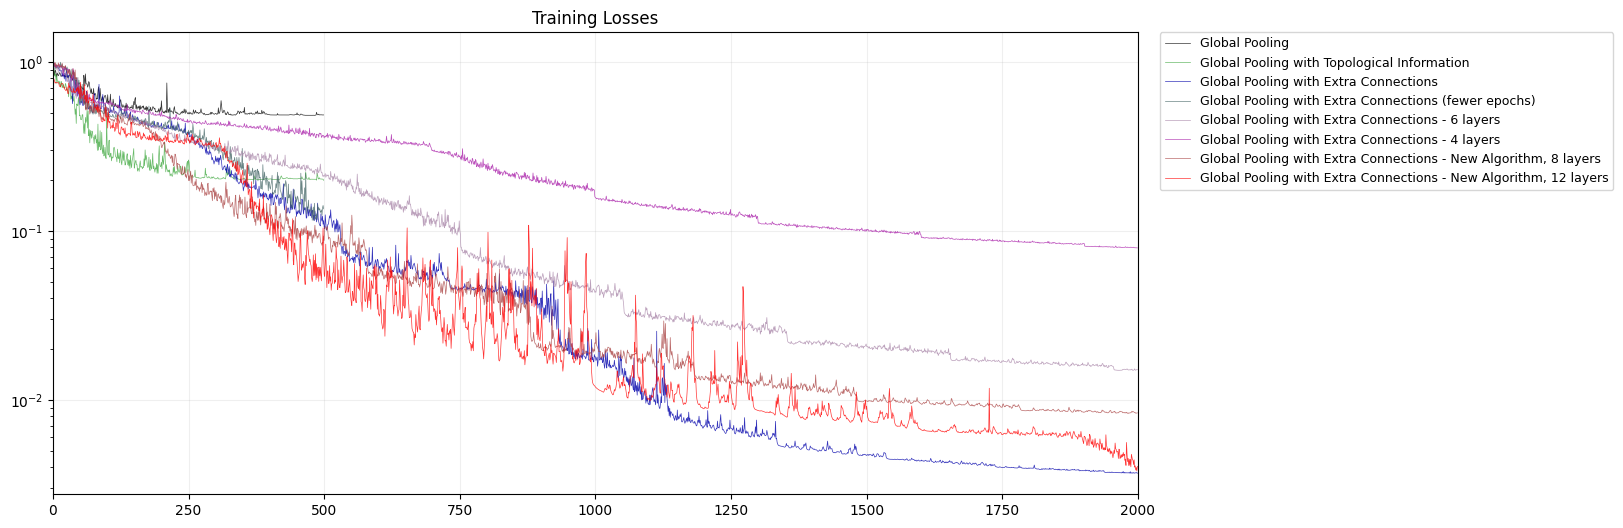

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

loss_1208_topo = pd.read_csv('../genconv/1209_pool_topology/losses.csv')
loss_1208_pool = pd.read_csv('../genconv/1208_pool/losses.csv')
loss_1208_conn = pd.read_csv('../genconv/1208_conn/losses.csv')
loss_1210_conn = pd.read_csv('../genconv/1210_conn/losses.csv')
loss_1210_conn6 = pd.read_csv('../genconv/1210_conn_6/losses.csv')
loss_1210_conn4 = pd.read_csv('../genconv/1210_conn_4/losses.csv')
loss_1214_conn = pd.read_csv('../genconv/1214_conn/losses.csv')
loss_1214_conn12 = pd.read_csv('../genconv/1214_conn_12/losses.csv')

plt.figure(figsize=(14,6))
plt.yscale('log')
plt.title('Validation Losses (10% of samples not seen by model)')
plt.grid(alpha=0.2)
plt.plot(loss_1208_pool['val_loss'],label='Global Pooling, No Coarse Connections',color='#000000',alpha=0.8,linewidth=0.5)
plt.plot(loss_1208_topo['val_loss'],label='Global Pooling with Topological Information',color='#44aa44',alpha=0.8,linewidth=0.5)
plt.plot(loss_1208_conn['val_loss'],label='Global Pooling with Extra Connections (fewer epochs)',color='#446666',alpha=0.8,linewidth=0.5)
plt.plot(loss_1210_conn['val_loss'],label='Global Pooling with Extra Connections',color='#0000aa',alpha=0.8,linewidth=0.5)
plt.plot(loss_1210_conn6['val_loss'],label='Global Pooling with Extra Connections - 6 layers',color='#aa88aa',alpha=0.8,linewidth=0.5)
plt.plot(loss_1210_conn4['val_loss'],label='Global Pooling with Extra Connections - 4 layers',color='#aa22aa',alpha=0.8,linewidth=0.5)
plt.plot(loss_1214_conn['val_loss'],label='Global Pooling with Extra Connections - New Algorithm, 8 layers',color='#aa4444',alpha=0.8,linewidth=0.5)
plt.plot(loss_1214_conn12['val_loss'],label='Global Pooling with Extra Connections - New Algorithm, 12 layers',color='#ff0000',alpha=0.8,linewidth=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=9)
plt.xlim(0,2000)



plt.figure(figsize=(14,6))
plt.title('Training Losses')
plt.grid(alpha=0.2)
plt.yscale('log')
plt.plot(loss_1208_pool['train_loss'],label='Global Pooling',color='#000000',alpha=0.8,linewidth=0.5)
plt.plot(loss_1208_topo['train_loss'],label='Global Pooling with Topological Information',color='#44aa44',alpha=0.8,linewidth=0.5)
plt.plot(loss_1210_conn['train_loss'],label='Global Pooling with Extra Connections',color='#0000aa',alpha=0.8,linewidth=0.5)
plt.plot(loss_1208_conn['train_loss'],label='Global Pooling with Extra Connections (fewer epochs)',color='#446666',alpha=0.8,linewidth=0.5)
plt.plot(loss_1210_conn6['train_loss'],label='Global Pooling with Extra Connections - 6 layers',color='#aa88aa',alpha=0.8,linewidth=0.5)
plt.plot(loss_1210_conn4['train_loss'],label='Global Pooling with Extra Connections - 4 layers',color='#aa22aa',alpha=0.8,linewidth=0.5)
plt.plot(loss_1214_conn['train_loss'],label='Global Pooling with Extra Connections - New Algorithm, 8 layers',color='#aa4444',alpha=0.8,linewidth=0.5)
plt.plot(loss_1214_conn12['train_loss'],label='Global Pooling with Extra Connections - New Algorithm, 12 layers',color='#ff0000',alpha=0.8,linewidth=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize=9)
plt.xlim(0,2000)

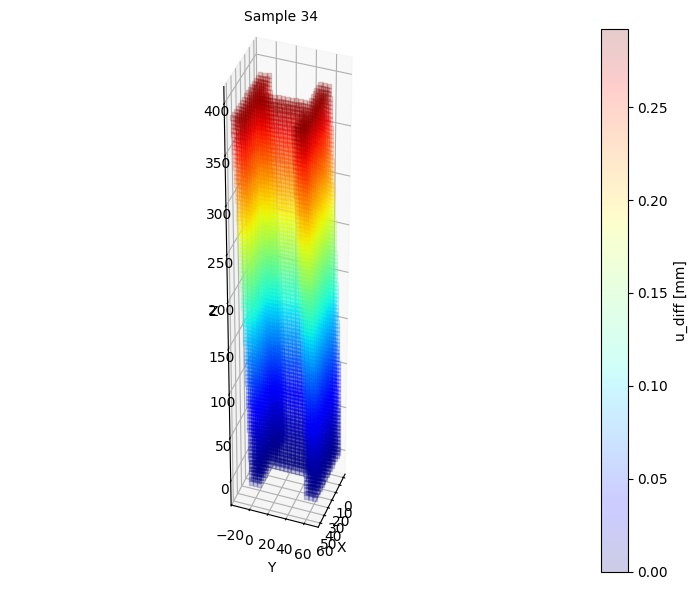

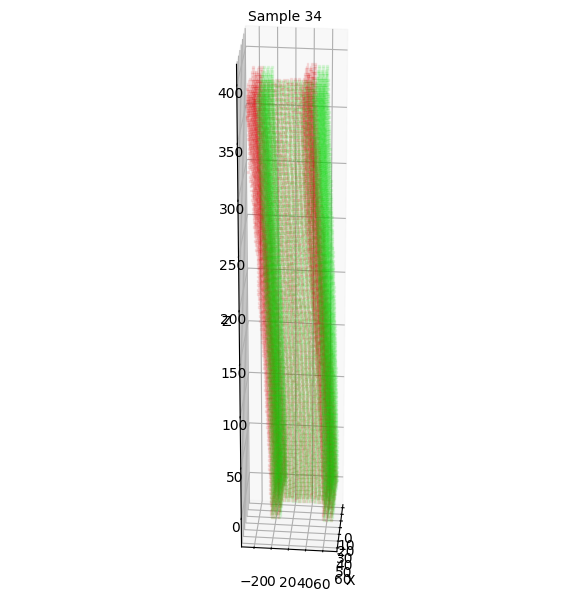

In [52]:
## Visualization - Matplotlib 3D Scatter Plot
import matplotlib.pyplot as plt
import numpy as np
import torch
alias = '1220_pool_conn'
#out_samples = torch.load("../base/test_dataset/preds_1208_conn.pt",weights_only=False)
out_samples = torch.load(f"../genconv/{alias}/preds_{alias}.pt",weights_only=False)
sample = 34

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
plt.title(f'Sample {sample}',fontsize=10)

#sc = ax.scatter(out_samples[sample]['nodes']['pos'],'k',alpha=0.3,label='initial position')
#ax[i,1].plot(out_samples[sample]['nodes']['pred_u'][:],alpha=0.3,label='predicted')

#ax.plot_trisurf(V[:,0],V[:,1],V[:,2],triangles=F,edgecolor='#888888',linewidth=lw,antialiased=True,color='#dddddd',alpha=0.1)

vis_scale = 50
u = out_samples[sample]['nodes']['y_u']
pos_init = out_samples[sample]['nodes']['pos']
pos_true = pos_init+out_samples[sample]['nodes']['y_u']*vis_scale
pos_pred = pos_init+out_samples[sample]['nodes']['pred_u']*vis_scale
#pos_diff = np.linalg.norm(pos_true-pos_pred,axis=-1)/vis_scale
pos_diff = np.linalg.norm(out_samples[sample]['nodes']['y_u'],axis=-1)
pos_diff_pred = np.linalg.norm(out_samples[sample]['nodes']['pred_u'],axis=-1)
mask = pos_diff > 1e-6
if mask.any():
    pos_delta = np.mean(np.abs(pos_diff_pred[mask] - pos_diff[mask]) / pos_diff[mask])
else:
    pos_delta = 0.0

#force_true = out_samples[sample]['nodes']['y_fint']
#force_pred = out_samples[sample]['nodes']['pred_fint']
#force_diff = np.linalg.norm(force_true-force_pred,axis=-1)

#sc = ax.scatter(pos_init[:,0],pos_init[:,1],pos_init[:,2],s=2,marker='s',c='#1111dd',alpha=0.2,depthshade=True)
#sc2 = ax.scatter(pos_true[:,0],pos_true[:,1],pos_true[:,2],s=2,marker='s',c='#11dd11',alpha=0.1,depthshade=True)
#sc3 = ax.scatter(pos_pred[:,0],pos_pred[:,1],pos_pred[:,2],s=2,marker='s',c='#dd1111',alpha=0.2,depthshade=True)
sc = ax.scatter(pos_true[:,0],pos_true[:,1],pos_true[:,2],s=10,marker='s',c=pos_diff,cmap='jet',alpha=0.2,depthshade=True)
plt.colorbar(sc, ax=ax, label='u_diff [mm]')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=40, azim=20)
ranges = np.ptp(out_samples[sample]['nodes']['pos'].T, axis=1)
ax.set_box_aspect(ranges)

plt.tight_layout()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
plt.title(f'Sample {sample}',fontsize=10)

#sc = ax.scatter(pos_init[:,0],pos_init[:,1],pos_init[:,2],s=10,marker='s',c='#1111dd',alpha=0.2,depthshade=True)
#plt.colorbar(sc, ax=ax, label='force_diff [N]')
sc2 = ax.scatter(pos_true[:,0],pos_true[:,1],pos_true[:,2],s=2,marker='s',c='#11dd11',alpha=0.1,depthshade=True)
sc3 = ax.scatter(pos_pred[:,0],pos_pred[:,1],pos_pred[:,2],s=2,marker='s',c='#dd1111',alpha=0.1,depthshade=True)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=30, azim=5)
ranges = np.ptp(out_samples[sample]['nodes']['pos'].T, axis=1)
ax.set_box_aspect(ranges)

plt.tight_layout()

(np.float64(-47.44161543818986),
 np.float64(389.08574900057084),
 np.float64(-19.467939810658553),
 np.float64(408.7904899001059))

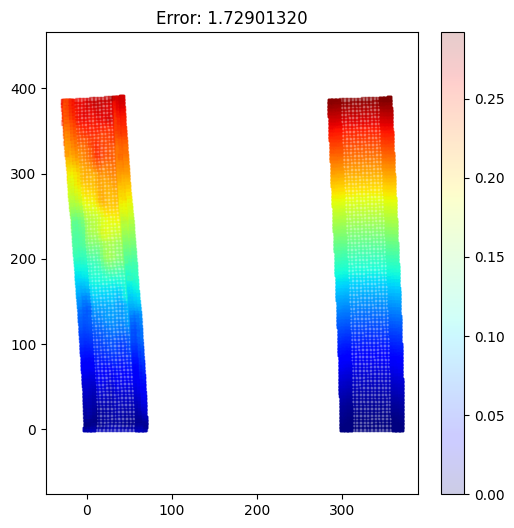

In [53]:
plt.figure(figsize=(6,6))
sc = plt.scatter(pos_pred[:,1],pos_pred[:,2],s=10,marker='s',c=pos_diff_pred,cmap='jet',alpha=0.2)
sc = plt.scatter(pos_true[:,1]+300,pos_true[:,2],s=10,marker='s',c=pos_diff,cmap='jet',alpha=0.2)
plt.colorbar()
plt.title(f'Error: {pos_delta:.8f}')
plt.axis('equal')

## Dirichlet loss
#x^t L x
#\sum (x_u - x_v) ^ 2
## GENConv softmax -> mean aggregation function
## check edge directionality & normalization

C:\Users\bm_tu\AppData\Local\Temp\ipykernel_40552\1356530558.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data.values(), labels=box_data.keys(), showfliers=False)


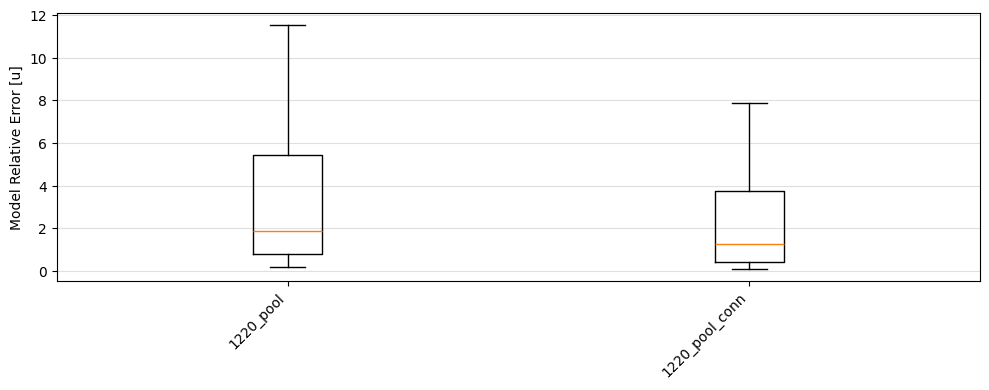

In [7]:
## Visualization - Matplotlib 3D Scatter Plot
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import torch

results = os.listdir("../genconv/")
box_data = {}
for folder in results:
    if folder == '.DS_Store':
        continue
    preds = glob.glob(f"../genconv/{folder}/preds*")
    if len(preds) < 1:
        continue
    out_samples = torch.load(preds[-1],weights_only=False)
    out_mean = []
    for sample in out_samples:
        pos_diff = np.linalg.norm(sample['nodes']['y_u'],axis=-1)
        pos_diff_pred = np.linalg.norm(sample['nodes']['pred_u'],axis=-1)
        mask = pos_diff > 1e-6
        if mask.any():
            pos_delta = np.mean(np.abs(pos_diff_pred[mask] - pos_diff[mask]) / pos_diff[mask])
        else:
            pos_delta = 0.0
        out_mean.append(pos_delta)
    out_mean = np.array(out_mean)
    box_data[folder] = out_mean
    
fig, ax = plt.subplots(figsize=(10,4))
plt.grid(axis='y',alpha=0.4)
ax.boxplot(box_data.values(), labels=box_data.keys(), showfliers=False)
ax.set_ylabel('Model Relative Error [u]')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()





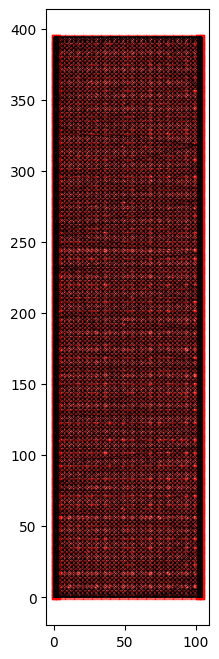

In [12]:
## Connectivity
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

edge_index = out_samples[sample][('nodes', 'adjacent', 'nodes')]['edge_index'].T.cpu().numpy()
pos = out_samples[sample]['nodes']['pos'].cpu().numpy()  # or whatever field holds your xyz coords

segments = pos[edge_index][:, :, 1:]   # keep x/y; drop [:, :, :3] if you want 3D
fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(LineCollection(segments, colors='k', linewidths=0.2, alpha=0.7))
ax.scatter(pos_init[:,1],pos_init[:,2],s=10,marker='s',c='r',alpha=0.2)
ax.autoscale()
ax.set_aspect('equal')
plt.show()


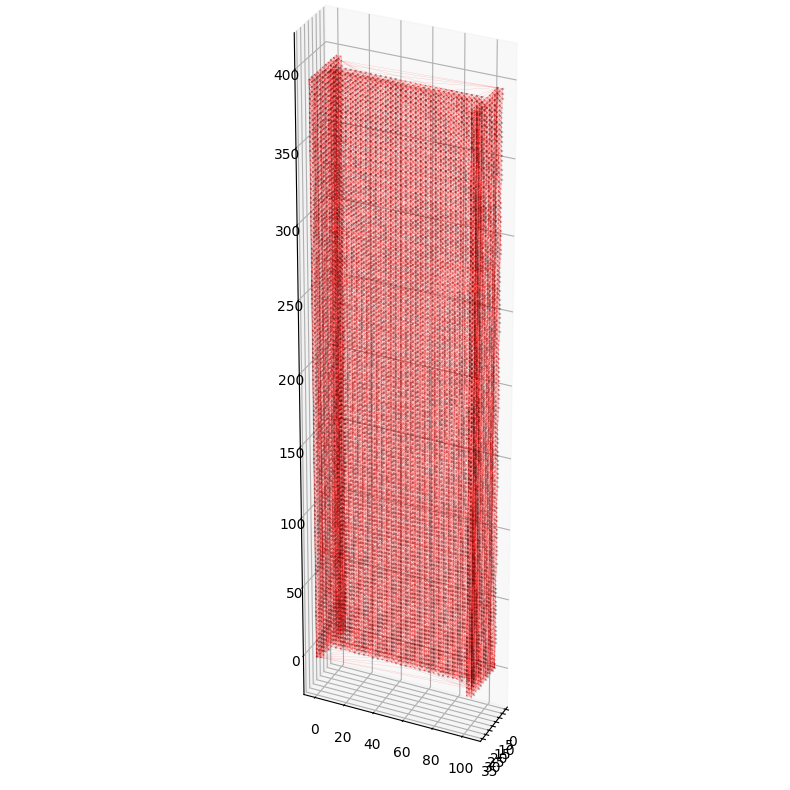

In [22]:
from mpl_toolkits.mplot3d.art3d import Line3DCollection

edge_index = out_samples[sample][('nodes','adjacent','nodes')]['edge_index'].T.cpu().numpy()
pos = out_samples[sample]['nodes']['pos'].cpu().numpy()
pos_init = pos.copy()

segments = pos[edge_index]                        # shape (num_edges, 2, 3)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.add_collection(Line3DCollection(segments, colors='r', linewidths=0.1, alpha=0.5))
ax.scatter(pos_init[:, 0], pos_init[:, 1], pos_init[:, 2],
           s=0.3, marker='s', c='k', alpha=0.2)

ax.set_box_aspect((pos[:,0].ptp(), pos[:,1].ptp(), pos[:,2].ptp()))
ax.view_init(elev=30, azim=25)
plt.tight_layout()
plt.show()


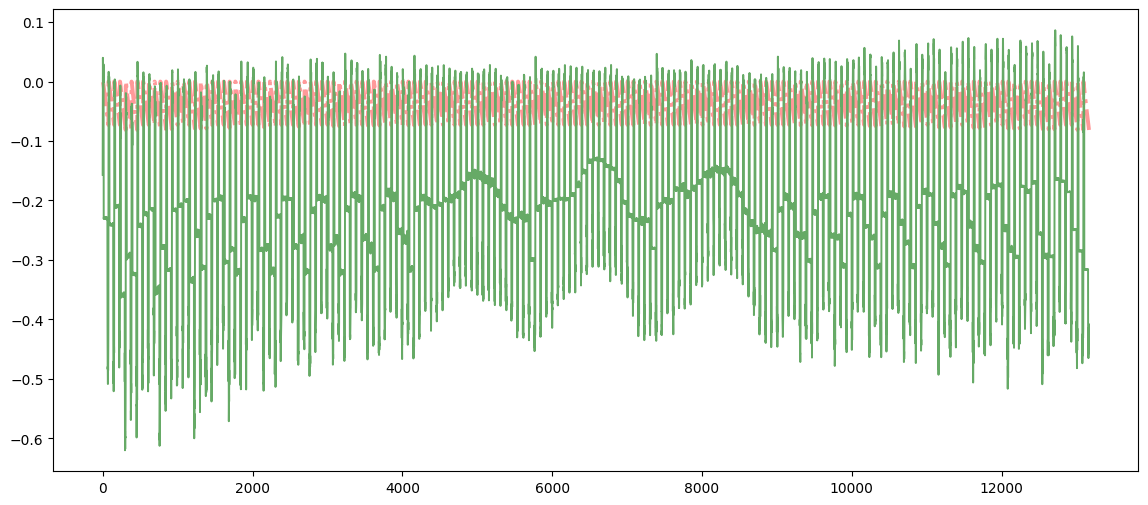

In [40]:
plt.figure(figsize=(14,6))
#plt.plot(train_set[8]['nodes']['y_u'],color='k')
#plt.plot(dataset[8]['nodes']['y_u'],color='r',linestyle='-.',linewidth=1.2)
plt.plot(out_samples[sample]['nodes']['y_u'][:,1],color='#ff9999',linestyle='-.',linewidth=2.8)
plt.plot(out_samples[sample]['nodes']['pred_u'][:,1],color='#66aa66',linestyle='-',linewidth=1.4)
plt.show()

In [26]:
from collections import Counter
import pyvista as pv
from collections import defaultdict
import numpy as np

vis_scale = 50

pos = out_samples[sample]['nodes']['pos'].cpu().numpy()        # (N,3)
edges = out_samples[sample][('nodes','adjacent','nodes')]['edge_index'].T.cpu().numpy()
pos_true = pos+(out_samples[sample]['nodes']['y_u']*vis_scale).cpu().numpy()
pos_pred = pos+(out_samples[sample]['nodes']['pred_u']*vis_scale).cpu().numpy()

adj = defaultdict(set)
for i, j in edges:
    adj[i].add(j)
    adj[j].add(i)

def find_quad_faces(adj):
    faces = set()

    for a in adj:
        for b in adj[a]:
            for c in adj[b]:
                if c == a: continue
                for d in adj[c]:
                    if d in adj[a] and d not in (a,b,c):    # closes the loop
                        quad = tuple(sorted([a,b,c,d]))
                        faces.add(quad)

    return np.array(list(faces))

faces = find_quad_faces(adj)

# Count duplicates
face_counts = Counter([tuple(sorted(f)) for f in faces])

surface_faces = np.array([f for f, c in face_counts.items() if c == 1])


# Convert to VTK-style quad faces
faces_pv = np.hstack([
    np.concatenate([[4], face]) for face in surface_faces
])

mesh = pv.PolyData(pos_pred, faces_pv)
#mesh = pv.PolyData(pos_true, faces_pv)

mesh.plot(
    show_edges=False,
    color="#8fa7ff",
    smooth_shading=False,
    opacity=0.95,
)


Widget(value='<iframe src="http://localhost:49675/index.html?ui=P_0x1aba6dde630_1&reconnect=auto" class="pyvis…

tensor(-3989.3345)


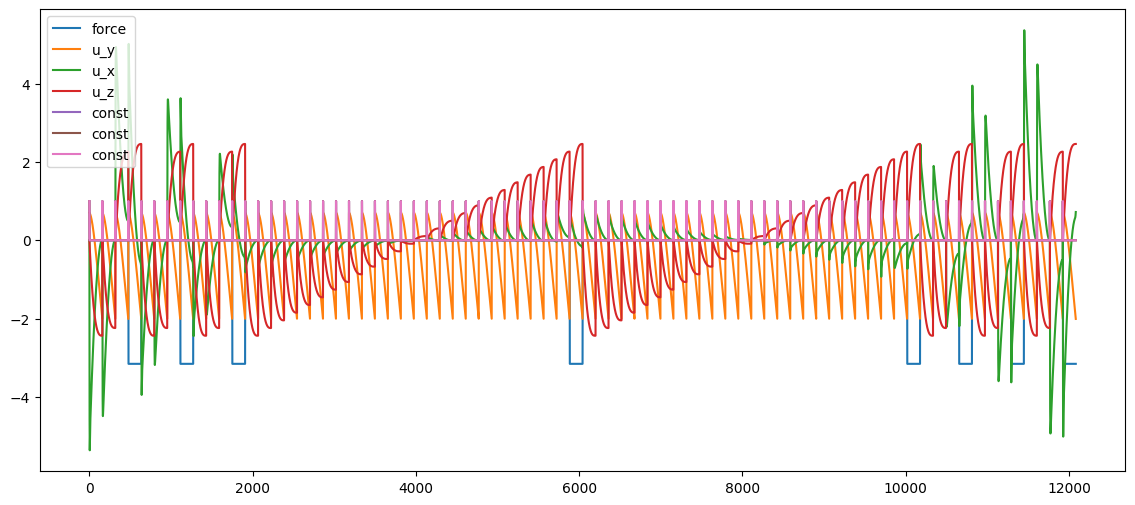

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(out_samples[sample]['nodes']['fext'][:,1],label='force')
plt.plot(out_samples[sample]['nodes']['y_u'][:,1],label='u_y')
plt.plot(out_samples[sample]['nodes']['y_u'][:,0],label='u_x')
plt.plot(out_samples[sample]['nodes']['y_u'][:,2],label='u_z')
plt.plot(out_samples[sample]['nodes']['x'][:,:3],label='const')
plt.legend()
#plt.xlim(0,2000)
print(out_samples[sample]['nodes']['fext'].sum())